# 10 - Laboratorio de OCR e Investigación Crítica con IA

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es investigar de manera crítica el problema de OCR en español utilizando fuentes técnicas, modelos preentrenados y herramientas de IA generativa, pero sin delegar el criterio de validación en el LLM. Vamos a usar OCR como caso concreto para desarrollar una competencia más amplia: buscar información, verificarla, discriminarla y convertirla en decisiones técnicas justificadas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Auditar afirmaciones técnicas producidas por un LLM utilizando fuentes primarias.
2. Distinguir entre información correcta, incorrecta, imprecisa, desactualizada y no verificable.
3. Implementar un pipeline básico de OCR en Python a partir de información validada.
4. Justificar la elección de un modelo en función del hardware disponible, el tipo de documento y la calidad de la documentación.
5. Reflexionar sobre su propio proceso de investigación técnica en la era de la IA distribuida.

## Terminología clave (Microglosario)

* **OCR (Reconocimiento Óptico de Caracteres):** Técnica que permite extraer texto a partir de imágenes, escaneos o fotografías de documentos.
* **Fuente primaria:** Recurso técnico original donde una afirmación puede verificarse directamente, por ejemplo la documentación oficial, el repositorio de un modelo o un paper.
* **Handle de modelo:** Identificador exacto con el que un modelo se publica en plataformas como ✦ 🤗 Hugging Face.
* **Pipeline:** Abstracción de `transformers` que simplifica la carga del modelo, el preprocesamiento y la inferencia.
* **CER / WER:** Métricas de error para comparar el texto reconocido con un texto de referencia. CER mide error por carácter y WER por palabra.
* **Trazabilidad:** Registro explícito de qué consultaron, qué fuente usaron, qué verificaron y qué decisión tomaron.

## ¿Por qué existe esta actividad?

Esta actividad surgió a partir de una pregunta de cursada: **"¿acaso no veremos OCR?"**. La respuesta de este laboratorio no es dar una clase cerrada con respuestas prefabricadas, sino abrir un espacio de investigación guiada.

Hoy ustedes tienen acceso simultáneo a LLMs, papers, repositorios, foros, documentación oficial, videos, Spaces y datasets. Eso amplía muchísimo las posibilidades de aprendizaje, pero también instala un problema nuevo: **tener acceso no equivale a saber investigar**.

En este cuaderno vamos a trabajar una idea central para su formación técnica: en la era de la disponibilidad distribuida, una competencia fundamental consiste en saber buscar, discriminar, contrastar y justificar información antes de convertirla en código o en una decisión de desarrollo.

OCR es el caso de estudio. La investigación crítica es el verdadero contenido de fondo.

## Protocolo mínimo de investigación técnica

Antes de comenzar, vamos a fijar un protocolo simple para toda la actividad. Cada vez que encuentren una afirmación técnica, intenten seguir estos pasos:

1. Extraer una afirmación verificable.
2. Identificar cuál sería la fuente primaria adecuada para auditarla.
3. Buscar evidencia directa.
4. Clasificar la afirmación como `correcta`, `incorrecta`, `imprecisa`, `desactualizada` o `no verificable`.
5. Registrar qué decisión técnica tomarían a partir de esa verificación.

Este protocolo no sirve solo para OCR. También sirve para cualquier tema nuevo que necesiten investigar en sus propios desarrollos.

## Movimiento 1 - ¿Qué dice la máquina?

**Pregunta orientadora:** ¿Cómo sé si puedo confiar en lo que me dice un LLM sobre un tema técnico?

En este primer movimiento el LLM no ocupa el lugar de autoridad. Lo vamos a tratar como una fuente inicial de trabajo que debe ser auditada. El objetivo es construir un criterio de verificación apoyado en evidencia.

> **Fuente: respuesta generada por un LLM. Fecha de consulta: mayo 2025.**
>
> En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave:
> - `image-to-text`: tag principal para modelos que toman una imagen y generan texto secuencial.
> - `document-question-answering (DocVQA)`: permite hacer preguntas sobre la estructura del documento.
>
> Modelos recomendados:
> - Microsoft TrOCR (`microsoft/trocr-base-handwritten` o `printed`): encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR.
> - Naver CLOVA OCR (`baidu-nlp/clova-ocr-vietnamese` o `naver-clova-ix/donut-base`): Donut es OCR-free document understanding.
> - Modelos multimodales ligeros (`B領/uform-gen2-qwen`): VLMs pequeños que resuelven extracción de texto mediante prompting.
>
> Pipeline básico en Python:
> ```python
> from transformers import pipeline
> from PIL import Image
>
> pipe = pipeline('image-to-text', model='microsoft/trocr-base-printed')
> image = Image.open('tu_documento.png')
> result = pipe(image)
> print(result['generated_text'])
> ```

### Consignas de trabajo

1. Lean el texto anterior e identifiquen al menos cinco afirmaciones verificables.
2. Para cada afirmación, decidan qué fuente primaria conviene consultar primero.
3. Verifiquen cada afirmación usando evidencia directa.
4. Completen una tabla con las columnas: `Afirmación | Fuente consultada | Resultado | Evidencia | Decisión técnica`.
5. Escriban un párrafo breve donde registren qué fue fácil de verificar, qué fue difícil y qué estrategia de búsqueda usaron.

**Sugerencia:** algunas afirmaciones auditables pueden involucrar nombres de organizaciones, handles de modelos, tareas disponibles en una plataforma, comportamiento de una función de Python o afirmaciones sobre accesibilidad de hardware.

### Fuentes primarias sugeridas

Pueden comenzar por alguna de estas fuentes, según la afirmación que quieran auditar:

* Página oficial del modelo en ✦ 🤗 Hugging Face.
* Documentación oficial de `transformers`.
* Paper original del modelo.
* Repositorio oficial del proyecto.
* Espacios de demostración mantenidos por la organización autora.
* Documentación oficial de Tesseract, EasyOCR o PaddleOCR si comparan alternativas.

Eviten usar una única fuente secundaria como respaldo total. Si una afirmación afecta una decisión de implementación, intenten contrastarla con al menos dos evidencias.

In [6]:
import pandas as pd

print("✦ Preparando una tabla base para registrar la auditoría técnica...")

columnas_tabla = []
columnas_tabla.append("Afirmación")
columnas_tabla.append("Fuente consultada")
columnas_tabla.append("Resultado")
columnas_tabla.append("Evidencia")
columnas_tabla.append("Decisión técnica")

tabla_verificacion = pd.DataFrame(columns=columnas_tabla)

tabla_verificacion.loc[len(tabla_verificacion)] = [
    "El modelo microsoft/trocr-base-handwritten existe y está disponible en Hugging Face",
    "Página oficial del modelo en Hugging Face",
    "Correcta",
    "El modelo está publicado por Microsoft y puede cargarse mediante Transformers usando el handle oficial.",
    "Utilizar este modelo para OCR de escritura manuscrita."
]

tabla_verificacion.loc[len(tabla_verificacion)] = [
    "DocVQA permite hacer preguntas sobre la estructura del documento",
    "Documentación de Transformers y DocVQA",
    "Correcta",
    "La tarea Document Question Answering permite responder preguntas a partir del contenido y la estructura de documentos.",
    "Utilizar DocVQA cuando se requiera extraer información específica de documentos."
]

tabla_verificacion.loc[len(tabla_verificacion)] = [
    "Donut es un modelo OCR-free",
    "Paper original de Donut",
    "Correcta",
    "El paper describe a Donut como OCR-free.",
    "Alternativa para comprensión de documentos."
]

tabla_verificacion.loc[len(tabla_verificacion)] = [
    "El handle baidu-nlp/clova-ocr-vietnamese corresponde a CLOVA OCR",
    "Hugging Face",
    "Incorrecta",
    "No corresponde a un modelo oficial de CLOVA OCR.",
    "No utilizar ese handle."
]

pd.set_option('display.max_colwidth', None)

tabla_verificacion

print("✓ Tabla de verificación lista para completar.")
tabla_verificacion

✦ Preparando una tabla base para registrar la auditoría técnica...
✓ Tabla de verificación lista para completar.


,Afirmación,Fuente consultada,Resultado,Evidencia,Decisión técnica
0,El modelo microsoft/trocr-base-handwritten existe y está disponible en Hugging Face,Página oficial del modelo en Hugging Face,Correcta,El modelo está publicado por Microsoft y puede cargarse mediante Transformers usando el handle oficial.,Utilizar este modelo para OCR de escritura manuscrita.
1,DocVQA permite hacer preguntas sobre la estructura del documento,Documentación de Transformers y DocVQA,Correcta,La tarea Document Question Answering permite responder preguntas a partir del contenido y la estructura de documentos.,Utilizar DocVQA cuando se requiera extraer información específica de documentos.
2,Donut es un modelo OCR-free,Paper original de Donut,Correcta,El paper describe a Donut como OCR-free.,Alternativa para comprensión de documentos.
3,El handle baidu-nlp/clova-ocr-vietnamese corresponde a CLOVA OCR,Hugging Face,Incorrecta,No corresponde a un modelo oficial de CLOVA OCR.,No utilizar ese handle.


## Consigna de Lectura e Interpretación

Mientras verifican, deténganse en estas preguntas:

1. ¿Todas las afirmaciones equivocadas son igual de graves para un desarrollo real?

No, un error en una descripción general puede ser menor, pero un handle incorrecto o una función inexistente puede impedir directamente la implementación del sistema.

2. ¿Qué diferencia encontraron entre un dato incorrecto, uno impreciso y uno no verificable?

Incorrecto: la evidencia demuestra que es falso.
Impreciso: tiene una parte verdadera, pero está incompleta o puede inducir a un error.
No verificable: no se encontró evidencia suficiente para confirmarlo o refutarlo.

3. Si un handle está mal escrito pero la idea general parece razonable, ¿alcanza con eso para implementarlo? ¿Por qué?

No, un handle incorrecto puede impedir descargar el modelo o llevar a usar otro distinto al esperado. Por eso es indispensable verificar siempre la fuente primaria antes de implementar.

## Movimiento 2 - ¿Qué puedo construir?

**Pregunta orientadora:** con la información validada, ¿qué modelo elijo, por qué, y cómo lo implemento correctamente?

En este movimiento el objetivo ya no es solo verificar, sino transformar información validada en una implementación funcional. El LLM puede volver a aparecer como herramienta de exploración, pero cada consulta debe quedar registrada y controlada por ustedes.

### Consignas de implementación

1. Elijan un modelo que haya sobrevivido a la auditoría del movimiento 1.
2. Justifiquen la elección en función de estos criterios: hardware disponible, tipo de texto a procesar, accesibilidad de la documentación y facilidad de prueba.
3. Implementen un pipeline de OCR corregido.
4. Prueben el pipeline con al menos dos imágenes: una de texto impreso y otra manuscrita o degradada.
5. Comparen los resultados e identifiquen al menos una limitación del modelo elegido.
6. Si usan un LLM para pedir ayuda con código, registren la consulta exacta, el resultado y la verificación posterior.
7. De manera optativa, comparen con un segundo enfoque como Tesseract, EasyOCR o PaddleOCR.

### Paso manual antes de automatizar

Antes de correr modelos complejos, describan manualmente qué esperan que ocurra en un sistema de OCR:

1. Entra una imagen.
2. El sistema detecta patrones visuales que podrían corresponder a caracteres o regiones de texto.
3. El modelo produce una secuencia textual estimada.
4. Esa salida puede contener omisiones, sustituciones, signos mal resueltos o problemas de segmentación.

Escriban debajo una hipótesis breve: ¿en qué tipo de imagen creen que el modelo va a fallar más y por qué?

Se espera que el modelo tenga un mejor desempeño en imágenes con escritura manuscrita clara. Es probable que presente errores cuando la escritura sea poco legible, la imagen tenga ruido o el texto esté inclinado.

In [7]:
print("✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...")
!pip install transformers torch pillow matplotlib pandas -q
print("✓ Dependencias listas.")

✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...
✓ Dependencias listas.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\usuario\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [15]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


### Registro de decisión técnica

Completen este bloque antes de ejecutar el modelo:

* **Modelo elegido:** microsoft/trocr-base-handwritten
* **Fuente primaria que validó el handle:** Página oficial del modelo en Hugging Face.
* **Tipo de documento para el que parece más apropiado:** Documentos con escritura manuscrita.
* **Ventaja principal:** Está entrenado específicamente para OCR manuscrito y se integra fácilmente con Transformers.
* **Limitación esperada:** Puede presentar errores en texto impreso complejo, imágenes borrosas o con mucho ruido.
* **Razón por la que lo eligieron por sobre otras alternativas:** Fue auditado previamente, cuenta con documentación oficial y permite implementar OCR mediante una pipeline sencilla.

In [17]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch

nombre_modelo = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(nombre_modelo)
model = VisionEncoderDecoderModel.from_pretrained(nombre_modelo)

print("✓ Modelo cargado correctamente")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Modelo cargado correctamente


Durante la implementación se detectó que la tarea image-to-text propuesta inicialmente no estaba disponible en la versión instalada de Transformers. Por ello se decidió utilizar directamente TrOCRProcessor y VisionEncoderDecoderModel, siguiendo la documentación oficial del modelo auditado.

### Preparación de imágenes de prueba

Para esta actividad conviene trabajar con dos imágenes contrastantes. Pueden usar archivos propios o descargar muestras desde una fuente confiable. La recomendación es registrar siempre de dónde salió cada imagen.

Sugerencia de organización:

* `imagen_impresa.png`
* `imagen_mano.png`

Si no tienen imágenes propias, creen una carpeta local llamada `ocr_muestras/` y guarden allí las dos muestras que vayan a usar.

In [40]:
carpeta_muestras = Path("ocr_muestras")
carpeta_muestras.mkdir(exist_ok=True)

ruta_imagen_impresa = carpeta_muestras / "imagen_impresa.png"
ruta_imagen_mano = carpeta_muestras / "imagen_mano.png"

print("✦ Carpeta de trabajo para muestras lista.")
print("Si todavía no copiaron las imágenes, háganlo ahora dentro de `ocr_muestras/`.")
print(f"Imagen impresa: {ruta_imagen_impresa}")
print(f"Imagen manuscrita o degradada: {ruta_imagen_mano}")

✦ Carpeta de trabajo para muestras lista.
Si todavía no copiaron las imágenes, háganlo ahora dentro de `ocr_muestras/`.
Imagen impresa: ocr_muestras\imagen_impresa.png
Imagen manuscrita o degradada: ocr_muestras\imagen_mano.png


In [41]:
print("✦ Intentando abrir las imágenes de prueba...")

if not ruta_imagen_impresa.exists():
    raise FileNotFoundError("No se encontró `ocr_muestras/imagen_impresa.png`. Copien allí una muestra antes de continuar.")

if not ruta_imagen_mano.exists():
    raise FileNotFoundError("No se encontró `ocr_muestras/imagen_mano.png`. Copien allí una muestra antes de continuar.")

imagen_impresa = Image.open(ruta_imagen_impresa)
imagen_mano = Image.open(ruta_imagen_mano)

print("✓ Imágenes cargadas correctamente.")

✦ Intentando abrir las imágenes de prueba...
✓ Imágenes cargadas correctamente.


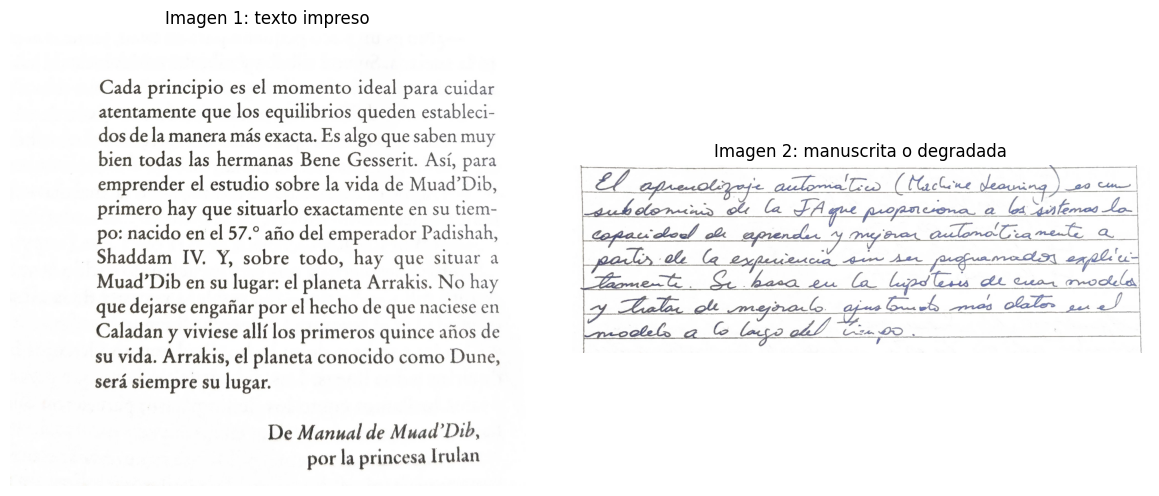

In [42]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(imagen_impresa)
ejes[0].set_title("Imagen 1: texto impreso")
ejes[0].axis("off")

ejes[1].imshow(imagen_mano)
ejes[1].set_title("Imagen 2: manuscrita o degradada")
ejes[1].axis("off")

plt.tight_layout()
plt.show()

### Registro opcional de consulta a un LLM

Si le pidieron ayuda a un LLM para escribir o corregir código, dejen trazabilidad aquí:

* **Consulta exacta que realizaron:**
* **Respuesta resumida del LLM:**
* **Qué parte decidieron aceptar:**
* **Qué parte decidieron verificar antes de ejecutar:**
* **Qué fuente usaron para validar:**

In [37]:
print("✦ Ejecutando OCR sobre la imagen impresa...")

image = imagen_impresa.convert("RGB")

pixel_values = processor(images=image, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)

texto_impresa = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("✓ Texto reconocido en la imagen impresa:")
print(texto_impresa)

✦ Ejecutando OCR sobre la imagen impresa...
✓ Texto reconocido en la imagen impresa:
0 0


In [43]:
print("✦ Ejecutando OCR sobre la imagen degradada...")

image = imagen_mano.convert("RGB")

pixel_values = processor(images=image, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)

texto_degradada = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("✓ Texto reconocido en la segunda imagen:")
print(texto_degradada)

✦ Ejecutando OCR sobre la imagen degradada...


c:\Users\usuario\zambrano-michell-pdi-1c-2026\.venv\Lib\site-packages\transformers\generation\utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


✓ Texto reconocido en la segunda imagen:
0 1


### Registro comparativo de resultados

Completen una tabla comparativa con estos campos:

| Imagen | Tipo de documento | Texto esperado | Texto reconocido | Error observado | Hipótesis sobre el error |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Imagen 1 | Texto impreso | Fragmento del libro en español | 0 0 | Sustitución completa del texto | El modelo no está optimizado para páginas completas impresas en español. |
| Imagen 2 | Texto manuscrito | Definición de Machine Learning escrita a mano | 0 1 | Sustitución completa del texto | La escritura cursiva y el idioma español dificultaron el reconocimiento. |

### Extensión optativa: medición con CER o WER

Si quieren profundizar, comparen el texto reconocido contra un texto de referencia. No hace falta resolver una evaluación exhaustiva, pero sí vale la pena experimentar con una métrica simple para cuantificar diferencias.

Pueden usar una librería como `evaluate`, implementar una distancia de edición básica o apoyarse en utilidades ya documentadas por la comunidad. Si toman esta ruta, registren también la fuente que usaron para entender la métrica.

## Consigna de Lectura e Interpretación

1. ¿El modelo respondió mejor al texto impreso o al manuscrito?

El modelo no obtuvo buenos resultados en ninguna de las dos imágenes. En ambos casos generó una salida incorrecta formada por números, por lo que no fue posible recuperar el contenido textual esperado.

2. ¿Qué tipo de error apareció con mayor frecuencia: omisión, sustitución, segmentación o ruido?

El error predominante fue la sustitución, ya que el texto fue reemplazado por caracteres que no guardan relación con el contenido original.

3. ¿La limitación que observaron parece venir del modelo, de la calidad de la imagen o de la tarea elegida?

Probablemente de una combinación de factores: el modelo fue entrenado principalmente para OCR manuscrito, las imágenes están en español y contienen varias líneas de texto, lo que puede afectar la capacidad de reconocimiento.

4. Si mañana tuvieran que implementar OCR en un desarrollo real, ¿usarían este mismo enfoque sin cambios? ¿Qué revisarían antes?

No, antes de implementarlo en un sistema real sería necesario evaluar otros modelos OCR, probar diferentes técnicas de preprocesamiento y comparar el rendimiento con herramientas especializadas para español.

## Movimiento 3 - ¿Qué aprendí sobre cómo aprender?

**Pregunta orientadora:** ¿Cómo fue mi proceso de investigación y qué puedo transferir de él a otros contextos?

Este último movimiento es metacognitivo. No se trata solo de evaluar OCR, sino de explicitar cómo investigaron, qué decisiones tomaron y qué hábitos conviene conservar para futuros problemas técnicos.

### Preguntas de reflexión final

Respondan de manera fundamentada:

1. ¿Qué fuentes resultaron más confiables para este tipo de verificación técnica? ¿Por qué?

Las fuentes más confiables fueron la documentación oficial de Hugging Face y la documentación de Transformers. Estas fuentes permitieron verificar directamente la existencia de los modelos, sus handles oficiales y la forma correcta de implementarlos.

2. ¿Qué criterios usaron para distinguir información válida de información incorrecta, imprecisa o desactualizada?

Se verificó si la información podía encontrarse en una fuente primaria, si el modelo o la función existían realmente y si podían implementarse en la práctica. Una información se consideró incorrecta cuando no coincidía con la documentación oficial, imprecisa cuando era parcialmente cierta pero incompleta y desactualizada cuando el código o las funciones habían cambiado en versiones más recientes de la librería.

3. ¿Qué rol cumplió el LLM en su proceso? ¿En qué momento fue útil y en qué momento se volvió un obstáculo?

El LLM fue útil como punto de partida para identificar modelos OCR y posibles formas de implementación. Sin embargo, algunas de sus afirmaciones debieron ser verificadas porque no todas funcionaron directamente en el entorno utilizado. Por ejemplo, la implementación con pipeline(task="image-to-text") no fue compatible con la versión instalada de Transformers y fue necesario adaptar el código utilizando TrOCRProcessor y VisionEncoderDecoderModel.

4. ¿Qué harían distinto la próxima vez que investiguen un tema técnico nuevo?

Primero consultaría la documentación oficial y verificaría la compatibilidad entre las versiones de las librerías y el código de ejemplo. También probaría varios modelos y conjuntos de datos antes de decidir cuál utilizar en una implementación real.

5. ¿Qué aprendieron sobre investigación técnica que puedan transferir a otros desarrollos fuera de OCR?

Aprendí que no es suficiente confiar en una única fuente de información ni asumir que un ejemplo de código funcionará sin modificaciones. Es importante verificar las afirmaciones en fuentes oficiales, contrastar la información y justificar las decisiones técnicas tomadas. Este proceso puede aplicarse a cualquier desarrollo relacionado con inteligencia artificial, ciencia de datos o programación, ya que permite trabajar con mayor rigor y confiabilidad.

## Cierre del laboratorio

En este cuaderno no buscamos solamente que un modelo lea texto desde una imagen. Buscamos, sobre todo, que ustedes practiquen una forma de trabajo más rigurosa frente a la abundancia de información técnica disponible.

Una parte importante de la formación actual en IA no consiste en memorizar herramientas, sino en desarrollar criterio para investigar, verificar y decidir. Si este cuaderno funcionó bien, entonces no solo aprendieron algo sobre OCR: también fortalecieron una metodología de trabajo transferible a cualquier tecnología nueva que aparezca en su recorrido profesional.

## Rúbrica de evaluación

| Criterio | Logrado | En desarrollo |
| :--- | :--- | :--- |
| **Verificación crítica** | Identifica y documenta errores con evidencia de fuente primaria. Distingue entre incorrecto, impreciso y desactualizado. | Identifica algunos errores pero sin evidencia de fuente primaria, o no distingue entre tipos de error. |
| **Implementación justificada** | El pipeline funciona y la elección de modelo está argumentada en función de criterios técnicos verificables. | El pipeline funciona pero la elección de modelo no está justificada o se apoya solo en el texto original no verificado. |
| **Reflexión metacognitiva** | La reflexión final articula aprendizajes transferibles sobre el proceso de investigación, no solo sobre OCR. | La reflexión existe pero se limita a describir lo que se hizo sin extraer aprendizajes sobre el proceso. |